# Experimento D: Batch vs streaming

**Objetivo:** Simular ambos modos de procesamiento, evaluar
latencia y throughput para distintos tamaños de lote y decidir cuando conviene cada arquitectura

###  1. Importación de librerías

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### 2. Configuración general

In [2]:
datos_dir = Path("../datos")
vis_dir = Path("../visualizaciones")
datos_dir.mkdir(exist_ok=True)
vis_dir.mkdir(exist_ok=True)
total_rows = 100_000
batch_sizes = [100, 500, 1000, 5000,10000,15000,20000]
repetitions = 3

# Semilla para reproducibilidad
np.random.seed(42)

### 3. Generación de datos

In [3]:
df = pd.DataFrame({
    "a": np.random.rand(total_rows),
    "b": np.random.rand(total_rows),
    "c": np.random.randint(1, 1000, total_rows)
})
df.head()

,a,b,c
0,0.374540,0.580779,840
1,0.950714,0.526972,553
2,0.731994,0.351037,54
3,0.598658,0.493213,10
4,0.156019,0.365097,971


### 4. Función de procesamiento

In [4]:
def procesar_bloque(df_block):
    resultado = df_block.copy()
    resultado["d"] = np.log(resultado["a"] + 1)
    resultado["e"] = resultado["b"] ** 2
    resultado["f"] = resultado["c"] * resultado["a"]
    return resultado

### 5. Simulación de batch

In [5]:
def ejecutar_batch(df, batch_size):
    latencias = []
    total_inicio = time.perf_counter()
    for i in range(0, len(df), batch_size):
        bloque = df.iloc[i:i + batch_size]
        inicio = time.perf_counter()
        _ = procesar_bloque(bloque)
        fin = time.perf_counter()
        latencias.append(fin - inicio)
    total_fin = time.perf_counter()
    tiempo_total = total_fin - total_inicio
    throughput = len(df) / tiempo_total
    latencia_promedio = np.mean(latencias)
    return latencia_promedio, throughput, tiempo_total

### 6. Simulación de streaming

In [6]:
def ejecutar_streaming(df):
    latencias = []
    total_inicio = time.perf_counter()
    for i in range(len(df)):
        fila = df.iloc[i:i + 1]
        inicio = time.perf_counter()
        _ = procesar_bloque(fila)
        fin = time.perf_counter()
        latencias.append(fin - inicio)
    total_fin = time.perf_counter()
    tiempo_total = total_fin - total_inicio
    throughput = len(df) / tiempo_total
    latencia_promedio = np.mean(latencias)
    return latencia_promedio, throughput, tiempo_total

### 7. Ejecución del experimento

In [7]:
resultados_d = []
# Primero medimos streaming una sola vez por repetición
streaming_lat = []
streaming_thr = []
streaming_total = []
for _ in range(repetitions):
    lat, thr, total = ejecutar_streaming(df)
    streaming_lat.append(lat)
    streaming_thr.append(thr)
    streaming_total.append(total)
resultados_d.append({
    "modo": "streaming",
    "batch_size": 1,
    "latencia_promedio_s": np.mean(streaming_lat),
    "throughput_filas_s": np.mean(streaming_thr),
    "tiempo_total_s": np.mean(streaming_total)
})
# Luego medimos batch para cada tamaño de lote
for batch_size in batch_sizes:
    batch_lat = []
    batch_thr = []
    batch_total = []
    for _ in range(repetitions):
        lat, thr, total = ejecutar_batch(df, batch_size)
        batch_lat.append(lat)
        batch_thr.append(thr)
        batch_total.append(total)
    resultados_d.append({
        "modo": "batch",
        "batch_size": batch_size,
        "latencia_promedio_s": np.mean(batch_lat),
        "throughput_filas_s": np.mean(batch_thr),
        "tiempo_total_s": np.mean(batch_total)
    })
df_resultados_d = pd.DataFrame(resultados_d)
df_resultados_d

,modo,batch_size,latencia_promedio_s,throughput_filas_s,tiempo_total_s
0,streaming,1,0.000384,2.534029e+03,39.479684
1,batch,100,0.000386,2.518030e+05,0.397158
2,batch,500,0.000397,1.226769e+06,0.081520
3,batch,1000,0.000393,2.476007e+06,0.040391
4,batch,5000,0.000429,1.137526e+07,0.008812
5,batch,10000,0.000438,2.233514e+07,0.004483
6,batch,15000,0.000479,2.915815e+07,0.003449
7,batch,20000,0.000523,3.771791e+07,0.002675


### 8. Guardar resultados

In [8]:
# Guardamos resultados en CSV
df_resultados_d.to_csv(datos_dir / "resultados_experimento_d.csv", index=False)
print("Resultados guardados correctamente.")

Resultados guardados correctamente.


### 9. Gráfico de latencia

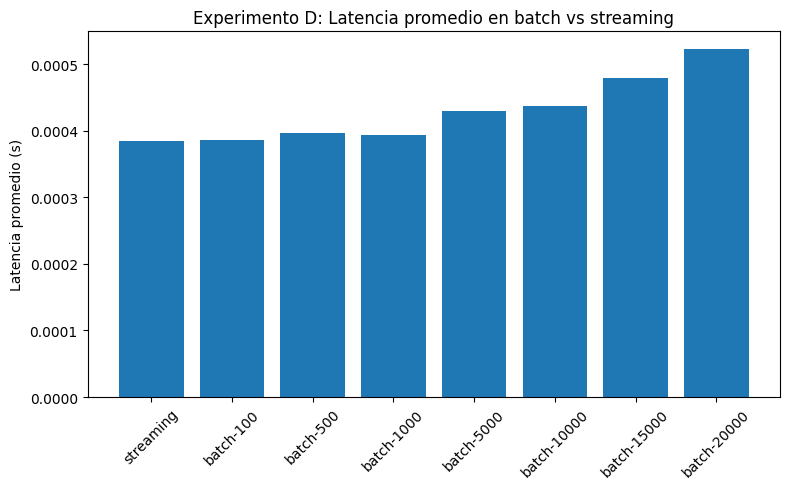

In [9]:
plt.figure(figsize=(8, 5))
labels = df_resultados_d.apply(
    lambda row: "streaming" if row["modo"] == "streaming" else f"batch-{row['batch_size']}",
    axis=1
)
plt.bar(labels, df_resultados_d["latencia_promedio_s"])
plt.ylabel("Latencia promedio (s)")
plt.title("Experimento D: Latencia promedio en batch vs streaming")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(vis_dir / "grafico_experimento_d_latencia.png", dpi=300)
plt.show()

### 10. Gráfico de throughput

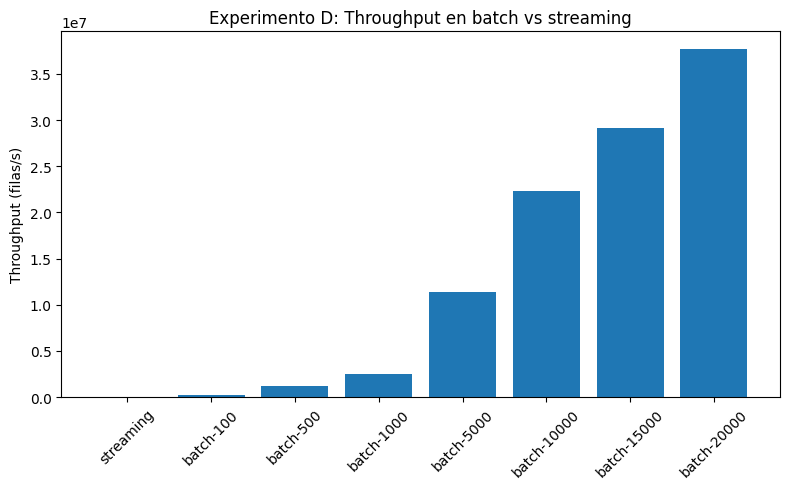

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(labels, df_resultados_d["throughput_filas_s"])
plt.ylabel("Throughput (filas/s)")
plt.title("Experimento D: Throughput en batch vs streaming")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(vis_dir / "grafico_experimento_d_throughput.png", dpi=300)
plt.show()

### 11. Gráfico combinado

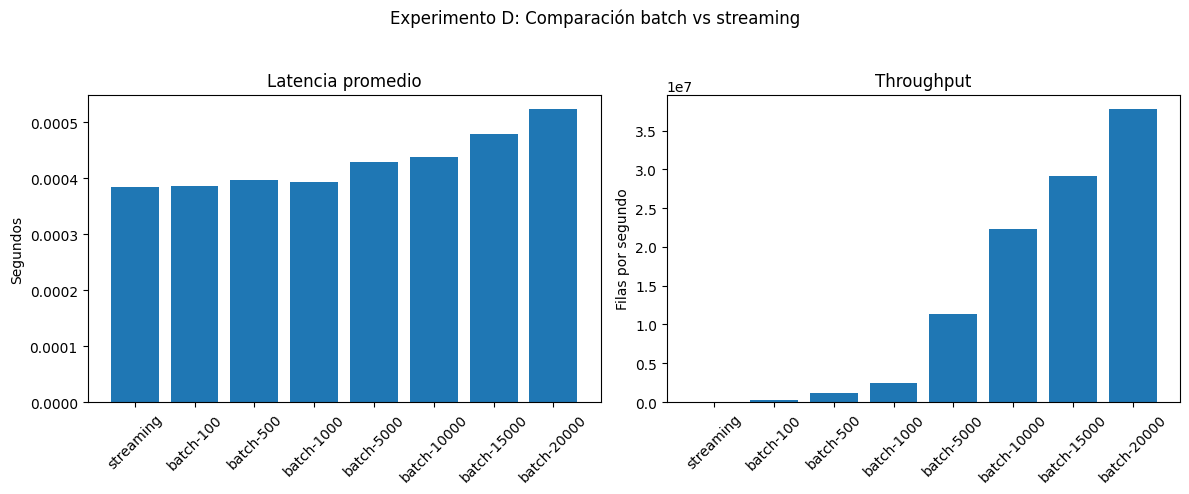

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Latencia
axes[0].bar(labels, df_resultados_d["latencia_promedio_s"])
axes[0].set_title("Latencia promedio")
axes[0].set_ylabel("Segundos")
axes[0].tick_params(axis="x", rotation=45)
# Throughput
axes[1].bar(labels, df_resultados_d["throughput_filas_s"])
axes[1].set_title("Throughput")
axes[1].set_ylabel("Filas por segundo")
axes[1].tick_params(axis="x", rotation=45)
fig.suptitle("Experimento D: Comparación batch vs streaming")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(vis_dir / "grafico_experimento_d_completo.png", dpi=300)
plt.show()